<a href="https://colab.research.google.com/github/muhlis-id/Data-Science_240401010197_Muhlis/blob/main/Pertemuan11_Muhlis_240401010197.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pertemuan 11

Nama: MUHLIS
NIM: 240401010197
Kelas: IF405

In [1]:
# ============================================
# Segmentasi Pelanggan
# ============================================

Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


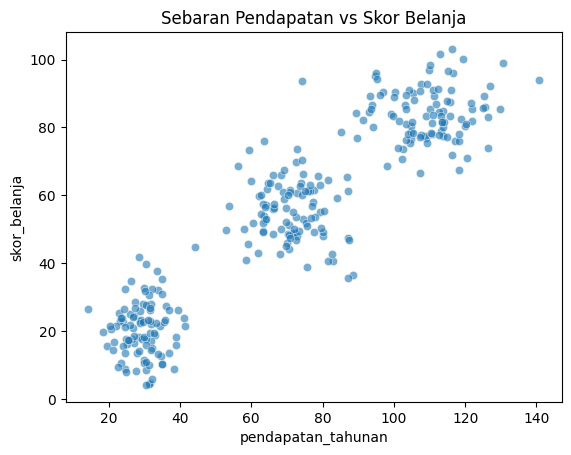

In [2]:
#Langkah 1: Generate & Eksplorasi Dataset

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)
grp1 = np.random.normal([30, 20], [6, 8], (100, 2)) # hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2)) # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2)) # boros
data = np.vstack([grp1, grp2, grp3])
df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))
print('Shape:', df.shape)
print(df.describe().round(2))
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6)
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.show()

In [3]:
#Langkah 2: Preprocessing Data

from sklearn.preprocessing import StandardScaler
X = df[['pendapatan_tahunan', 'skor_belanja']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling :', X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling : [1. 1.]


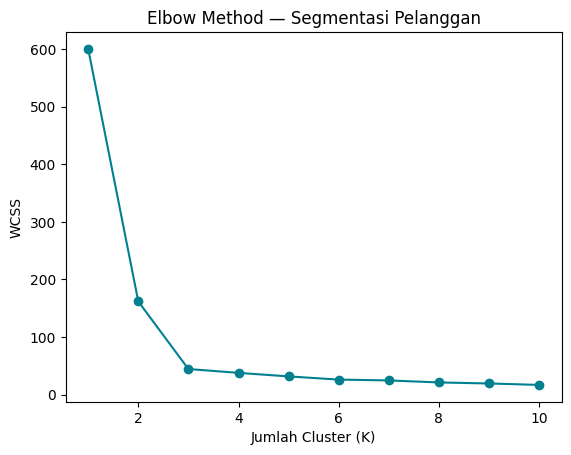

In [5]:
#Langkah 3: Metode Elbow untuk Menentukan K

from sklearn.cluster import KMeans
wcss = []
for k in range(1, 11):
  km = KMeans(n_clusters=k, random_state=42, init='k-means++')
  km.fit(X_scaled)
  wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o', color='#028090')
plt.xlabel('Jumlah Cluster (K)'); plt.ylabel('WCSS')
plt.title('Elbow Method — Segmentasi Pelanggan')
plt.show()
# Interpretasikan dalam sel Markdown berikutnya:
# - Di K berapa kurva mulai melandai (titik elbow)?
# - Apakah hasilnya sesuai dengan jumlah kelompok yang diharapkan?

In [6]:
#Langkah 4: Melatih Model K-Means

from sklearn.metrics import silhouette_score
model = KMeans(n_clusters=3, random_state=42, init='k-means++')
model.fit(X_scaled)
df['cluster'] = model.labels_
print(f'WCSS akhir : {model.inertia_:.3f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}')
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))

WCSS akhir : 44.556
Silhouette Score: 0.695
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08


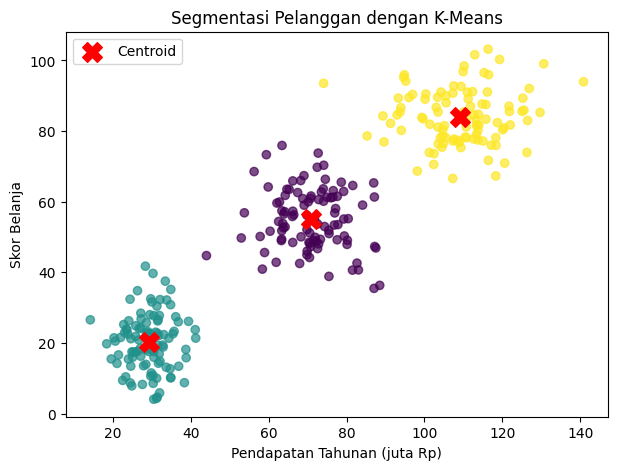

In [7]:
#Langkah 5: Visualisasi Hasil Clustering

centroids = scaler.inverse_transform(model.cluster_centers_)
plt.figure(figsize=(7, 5))
plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'],
c=df['cluster'], cmap='viridis', alpha=0.7)

plt.scatter(centroids[:, 0], centroids[:, 1],
c='red', marker='X', s=200, label='Centroid')
plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means')
plt.legend(); plt.show()
# Interpretasikan tiap cluster, misalnya:
# Cluster 0 = pendapatan rendah, belanja rendah -> segmen 'Hemat'
# Cluster 1 = pendapatan menengah, belanja menengah -> segmen 'Menengah'
# Cluster 2 = pendapatan tinggi, belanja tinggi -> segmen 'Boros/Premium'

Kesimpulan